In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load the student performance dataset

url = "https://raw.githubusercontent.com/Venu-HV/student-performance-prediction/main/student_performance.csv"

df = pd.read_csv(url)

# Display the first 5 rows
df.head()

,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks
0,2,65,55,60,58
1,3,70,60,65,63
2,4,75,65,70,68
3,5,80,70,75,74
4,6,85,75,80,81


In [ ]:
# Check dataset information

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (15, 5)

Column Names:
['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Final_Marks']

Missing Values:
Study_Hours         0
Attendance          0
Previous_Marks      0
Assignment_Score    0
Final_Marks         0
dtype: int64

Statistical Summary:


,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,4.733333,78.400000,69.400000,73.666667,73.533333
std,2.250926,11.752203,13.896557,13.541822,15.042163
min,1.000000,60.000000,45.000000,50.000000,48.000000
25%,3.000000,69.000000,59.000000,63.500000,62.000000
50%,5.000000,78.000000,70.000000,75.000000,74.000000
75%,6.500000,89.000000,80.000000,83.500000,85.500000
max,8.000000,95.000000,90.000000,95.000000,96.000000


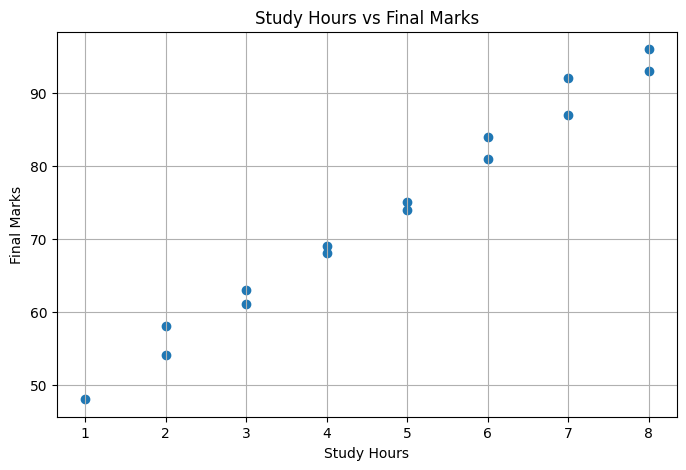

In [ ]:
# Visualize Study Hours vs Final Marks

plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours"], df["Final_Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.grid(True)
plt.show()

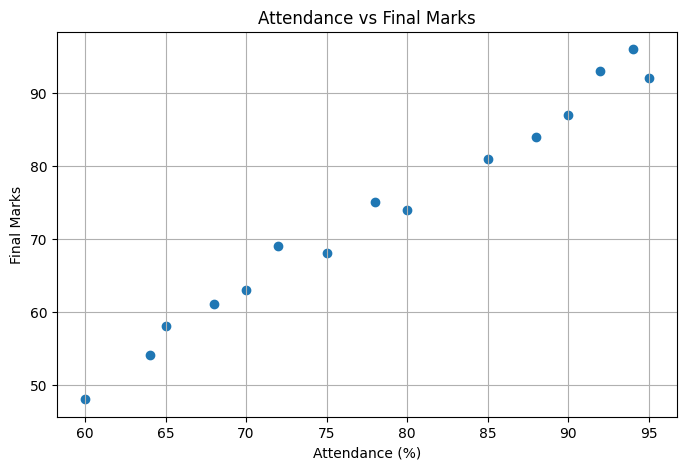

In [ ]:
# Visualize Attendance vs Final Marks

plt.figure(figsize=(8, 5))

plt.scatter(df["Attendance"], df["Final_Marks"])

plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")

plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Input features
X = df[["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]]

# Target variable
y = df["Final_Marks"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 12
Testing samples: 3


In [ ]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
# Make predictions on the test data

y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error (MAE): 0.4
Mean Squared Error (MSE): 0.32
R² Score: 0.99


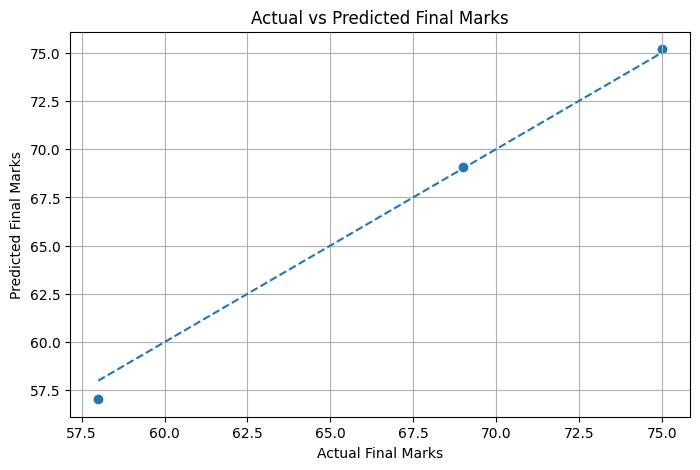

In [ ]:
# Actual vs Predicted Final Marks

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")

plt.grid(True)
plt.show()

In [ ]:
# Predict final marks for a new student

new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [85],
    "Previous_Marks": [75],
    "Assignment_Score": [80]
})

prediction = model.predict(new_student)

print("Predicted Final Marks:", round(prediction[0], 2))

Predicted Final Marks: 80.8


In [ ]:


print("Student Performance Prediction")
print("------------------------------")
print("Study Hours:", 6)
print("Attendance:", 85, "%")
print("Previous Marks:", 75)
print("Assignment Score:", 80)
print("Predicted Final Marks:", round(prediction[0], 2))

Student Performance Prediction
------------------------------
Study Hours: 6
Attendance: 85 %
Previous Marks: 75
Assignment Score: 80
Predicted Final Marks: 80.8
